# 🔬 Nonlinear Hybrid Unit Root Testing with `hybridnonlinur`

**A Comprehensive Tutorial with Real Financial Data**

---

This notebook demonstrates all **13 nonlinear unit root tests** implemented in the
`hybridnonlinur` Python library. We apply each test to real exchange rate and commodity
price data — domains where nonlinear mean reversion and structural breaks are prevalent.

### Tests Covered

| # | Test | Nonlinearity | Reference |
|---|------|-------------|----------|
| 1 | KSS | ESTAR | Kapetanios, Shin & Snell (2003) |
| 2 | Fourier-KSS | ESTAR + Fourier breaks | Christopoulos & Leon-Ledesma (2010) |
| 3 | Fourier-ADF | Linear + Fourier breaks | Enders & Lee (2012) |
| 4 | Fourier-KSS Bootstrap | ESTAR + Bootstrap CV | Christopoulos & Leon-Ledesma (2010) |
| 5 | Fourier-Kruse | ESTAR (c≠0) + Fourier | Güriş (2019) |
| 6 | FFKRUSE | Fractional Fourier Kruse | Biyikli & Hepsağ (2025) |
| 7 | Fourier-Sollis | AESTAR + Fourier | Ranjbar et al. (2018) |
| 8 | FFSOLLIS | Fractional Fourier Sollis | Biyikli & Hepsağ (2025) |
| 9 | Fourier-Sollis-ZM | AESTAR Zero-Mean | Hepkorucu & Çınar (2021) |
| 10 | QR-KSS | Quantile ESTAR | Li & Park (2018) |
| 11 | QR-Fourier-KSS | Quantile Fourier ESTAR | Bahmani-Oskooee et al. (2020) |
| 12 | KSS-FF | Fractional Fourier ESTAR | Omay, Corakci & Hasdemir (2021) |
| 13 | FWKSS | Haar Wavelet + Fourier-KSS | Aydin (Sakarya) |


In [1]:
# ── Installation & Imports ──
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from IPython.display import display, HTML, Markdown

import hybridnonlinur as hnur
print(f'hybridnonlinur v{hnur.__version__} loaded successfully ✓')


hybridnonlinur v1.0.0 loaded successfully ✓


## 1. Data: Real Exchange Rates & Commodity Prices

We use **Yahoo Finance** data via `yfinance` to download:
- **EUR/USD** exchange rate (log real exchange rate)
- **Gold prices** (log prices)
- **Crude Oil WTI** (log prices)


In [2]:
# ── Download Real Financial Data ──
try:
    import yfinance as yf
    tickers = {'EURUSD=X': 'EUR/USD', 'GC=F': 'Gold', 'CL=F': 'Crude Oil WTI'}
    data = {}
    for tick, name in tickers.items():
        df = yf.download(tick, start='2000-01-01', end='2024-12-31',
                         progress=False, auto_adjust=True)
        s = np.log(df['Close'].dropna().values.astype(float).ravel())
        # Resample to monthly (take last obs per month)
        idx = pd.DatetimeIndex(df['Close'].dropna().index)
        monthly = pd.Series(s, index=idx).resample('ME').last().dropna()
        data[name] = monthly.values
        print(f'{name}: {len(monthly)} monthly obs ({idx[0].year}–{idx[-1].year})')
except Exception as e:
    print(f'yfinance not available ({e}), using simulated data')
    np.random.seed(42)
    T = 300
    # Simulate nonlinear mean-reverting processes
    def sim_estar(T, theta=0.05, c=0):
        y = np.zeros(T)
        for t in range(1, T):
            G = 1 - np.exp(-theta * (y[t-1] - c)**2)
            y[t] = y[t-1] - 0.3 * G * (y[t-1] - c) + np.random.normal(0, 0.5)
        return y
    data = {
        'EUR/USD': sim_estar(T, theta=0.03),
        'Gold': np.cumsum(np.random.normal(0.001, 0.04, T)),
        'Crude Oil WTI': sim_estar(T, theta=0.02, c=0.5),
    }
    for name, s in data.items():
        print(f'{name}: {len(s)} monthly obs (simulated)')


EUR/USD: 253 monthly obs (2003–2024)


Gold: 293 monthly obs (2000–2024)


Crude Oil WTI: 293 monthly obs (2000–2024)


## 2. Visualizing the Data


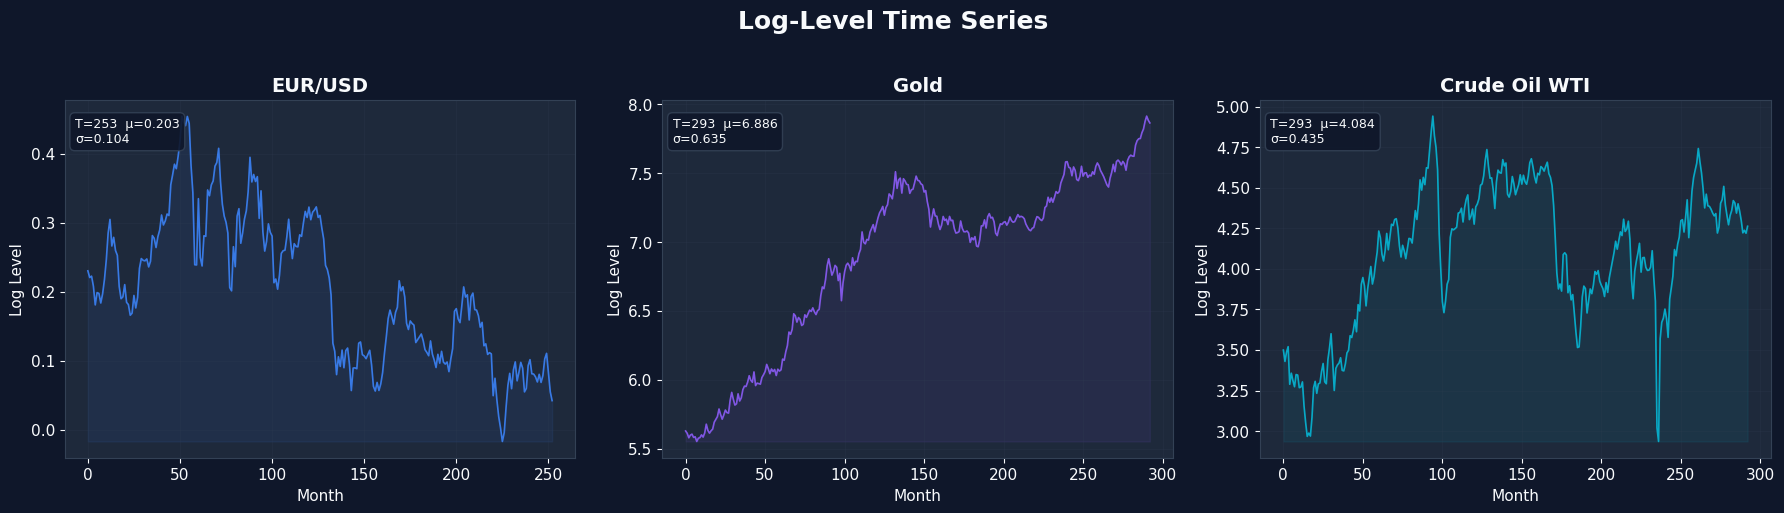

In [3]:
# ── Premium Dark Theme Setup ──
COLORS = {
    'bg': '#0F172A', 'card': '#1E293B', 'grid': '#334155',
    'text': '#F8FAFC', 'blue': '#3B82F6', 'purple': '#8B5CF6',
    'cyan': '#06B6D4', 'green': '#10B981', 'amber': '#F59E0B',
    'red': '#EF4444', 'pink': '#EC4899', 'indigo': '#6366F1',
}
PAL = [COLORS['blue'], COLORS['purple'], COLORS['cyan'],
       COLORS['green'], COLORS['amber'], COLORS['red']]

def setup_style():
    rcParams.update({
        'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['card'],
        'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
        'text.color': COLORS['text'], 'xtick.color': COLORS['text'],
        'ytick.color': COLORS['text'], 'grid.color': COLORS['grid'],
        'grid.alpha': 0.3, 'font.size': 11,
    })
setup_style()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, y) in enumerate(data.items()):
    ax = axes[i]
    t = np.arange(len(y))
    ax.plot(t, y, color=PAL[i], lw=1.2, alpha=0.9)
    ax.fill_between(t, y.min(), y, alpha=0.08, color=PAL[i])
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('Log Level')
    ax.grid(True, alpha=0.2)
    # Stats box
    stats_txt = f'T={len(y)}  μ={np.mean(y):.3f}\nσ={np.std(y):.3f}'
    ax.text(0.02, 0.95, stats_txt, transform=ax.transAxes, fontsize=9,
            va='top', bbox=dict(boxstyle='round,pad=0.4',
            facecolor=COLORS['bg'], edgecolor=COLORS['grid'], alpha=0.9))
fig.suptitle('Log-Level Time Series', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_series.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


---
## 3. KSS Family Tests

### 3.1 KSS — Kapetanios, Shin & Snell (2003)
Tests unit root against **ESTAR** alternative: $\Delta y_t = \delta y_{t-1}^3 [1 - \exp(-\theta y_{t-1}^2)] + \varepsilon_t$


In [4]:
# ── 3.1 KSS Test ──
series_name = list(data.keys())[0]
y = data[series_name]

r_kss = hnur.kss(y, model=2, pmax=12)
print(r_kss.summary())



  KSS Unit Root Test
---------------------  -------------------------------
                 Test  KSS
                Model  Intercept + Trend
       Test Statistic  -2.1304
Optimal Frequency (k)  0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -3.7700  |  No
             5% level  -3.0900  |  No
            10% level  -2.7700  |  No

            Reference  Kapetanios, Shin & Snell (2003)
---------------------  -------------------------------


### 3.2 Fourier-KSS — Christopoulos & Leon-Ledesma (2010)
Combines **Fourier structural breaks** with ESTAR nonlinearity.
Two-step: (1) Fourier detrend, (2) KSS on residuals.



  Fourier-KSS Unit Root Test
---------------------  -----------------------------------
                 Test  Fourier-KSS
                Model  Intercept
       Test Statistic  -3.1215
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -4.3500  |  No
             5% level  -3.5500  |  No
            10% level  -3.1700  |  No

     F-stat (Fourier)  225.1704
      F critical (5%)  4.9290

            Reference  Christopoulos & Leon-Ledesma (2010)
---------------------  -----------------------------------


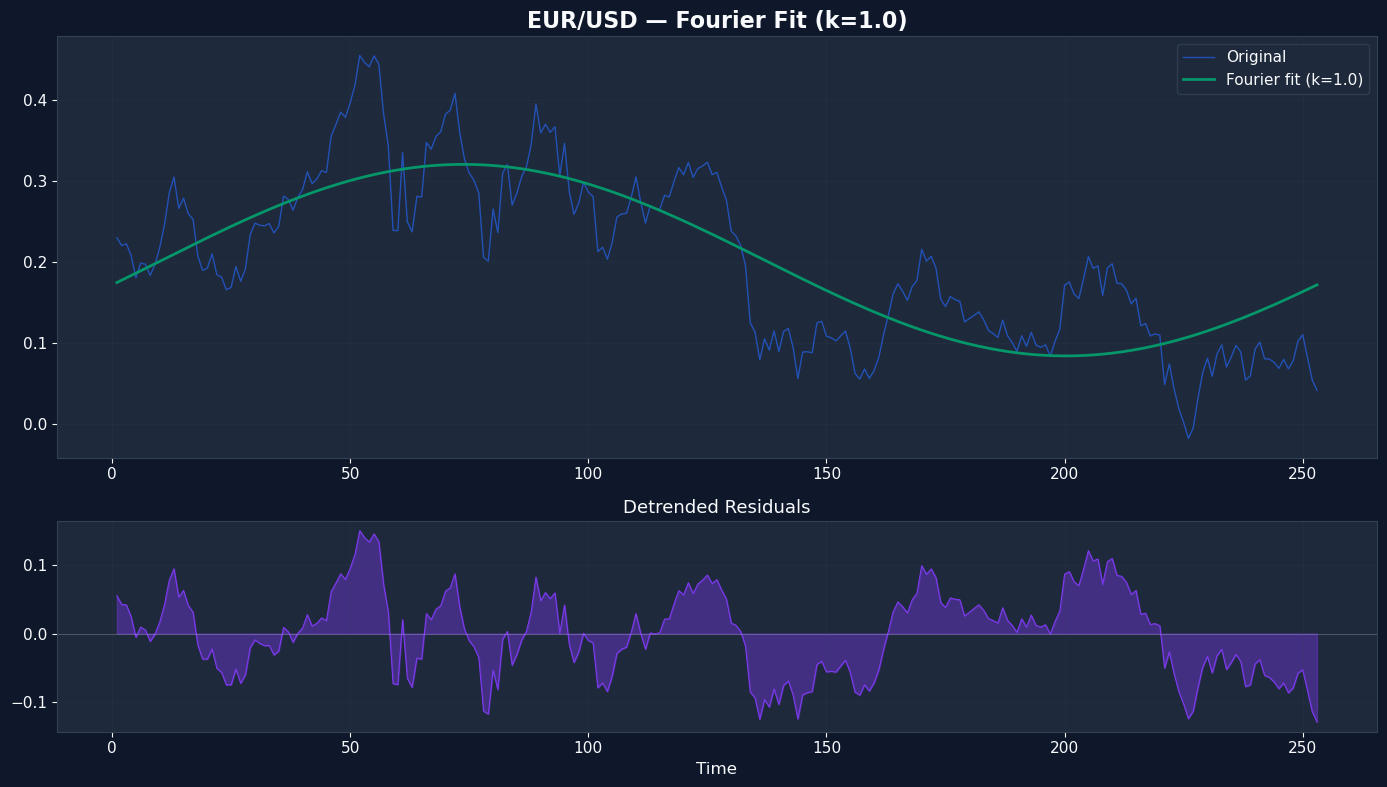

In [5]:
# ── 3.2 Fourier-KSS ──
r_fkss = hnur.fourier_kss(y, model=1, pmax=12)
print(r_fkss.summary())

# Visualize Fourier fit
fig = hnur.plot_series_with_fourier(y, model=1, k=r_fkss.optimal_k,
    title=f'{series_name} — Fourier Fit (k={r_fkss.optimal_k})')
plt.savefig('fig_fourier_fit.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


### 3.3 Fourier-ADF — Enders & Lee (2012)
Linear ADF augmented with Fourier terms to capture **smooth structural breaks**.


In [6]:
# ── 3.3 Fourier-ADF ──
r_fadf = hnur.fourier_adf(y, model=1, pmax=12)
print(r_fadf.summary())



  Fourier-ADF Unit Root Test
---------------------  --------------------------
                 Test  Fourier-ADF
                Model  Intercept
       Test Statistic  -3.0818
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -4.4200  |  No
             5% level  -3.8100  |  No
            10% level  -3.4900  |  No

     F-stat (Fourier)  225.1704
      F critical (5%)  4.9290

            Reference  Enders & Lee (2012)
---------------------  --------------------------


### 3.4 Fourier-KSS Bootstrap — Christopoulos & Leon-Ledesma (2010)
Sieve bootstrap critical values under H₀ (unit root).


In [7]:
# ── 3.4 Bootstrap (500 replications for speed) ──
r_boot = hnur.fourier_kss_bootstrap(y, model=1, pmax=12,
                                     test='FKSS', nboot=500)
print(r_boot.summary())



  Fourier-FKSS (Bootstrap) Unit Root Test
---------------------  -----------------------------------
                 Test  Fourier-FKSS (Bootstrap)
                Model  Intercept
       Test Statistic  -3.1215
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -4.3459  |  No
             5% level  -3.7169  |  No
            10% level  -3.4117  |  No

     F-stat (Fourier)  225.1704

            Reference  Christopoulos & Leon-Ledesma (2010)
---------------------  -----------------------------------


---
## 4. Kruse Family Tests

### 4.1 Fourier-Kruse — Güriş (2019)
ESTAR with **non-zero threshold** ($c \neq 0$): uses $\tau = t^2(\hat{\delta}_{2\perp}) + \mathbb{1}(\hat{\delta}_1<0) \cdot t^2(\hat{\delta}_1)$


In [8]:
# ── 4.1 Fourier-Kruse ──
r_fkruse = hnur.fourier_kruse(y, model=1, pmax=12)
print(r_fkruse.summary())



  Fourier-Kruse Unit Root Test
---------------------  --------------------------
                 Test  Fourier-Kruse
                Model  Intercept
       Test Statistic  11.1137
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  18.8200  |  No
             5% level  14.8000  |  No
            10% level  12.5200  |  No

     F-stat (Fourier)  225.1704
      F critical (5%)  4.9290

            Reference  Güriş (2019)
---------------------  --------------------------


### 4.2 FFKRUSE — Biyikli & Hepsağ (2025)
Extends Fourier-Kruse with **fractional frequencies** for finer break detection.


In [9]:
# ── 4.2 Fractional Frequency Kruse ──
r_ffkruse = hnur.ffkruse(y, model=1, pmax=12)
print(r_ffkruse.summary())



  FFKRUSE Unit Root Test
---------------------  --------------------------
                 Test  FFKRUSE
                Model  Intercept
       Test Statistic  12.0384
Optimal Frequency (k)  0.9
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  19.5600  |  No
             5% level  14.8600  |  No
            10% level  12.7000  |  No

     F-stat (Fourier)  252.5704
      F critical (5%)  4.9290

            Reference  Biyikli & Hepsağ (2025)
---------------------  --------------------------


---
## 5. Sollis / AESTAR Family Tests

### 5.1 Fourier-Sollis — Ranjbar et al. (2018)
Tests against **asymmetric ESTAR**: $\Delta v_t = \varphi_1 v_{t-1}^3 + \varphi_2 v_{t-1}^4 + \text{lags}$.
Joint F-test: $H_0: \varphi_1 = \varphi_2 = 0$.


In [10]:
# ── 5.1 Fourier-Sollis ──
r_fsollis = hnur.fourier_sollis(y, model=1, pmax=12)
print(r_fsollis.summary())



  Fourier-Sollis Unit Root Test
---------------------  --------------------------
                 Test  Fourier-Sollis
                Model  Intercept
       Test Statistic  5.4951
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  9.7800  |  No
             5% level  7.4720  |  No
            10% level  6.3950  |  No

     F-stat (Fourier)  225.1704
      F critical (5%)  4.9290

            Reference  Ranjbar et al. (2018)
---------------------  --------------------------


### 5.2 FFSOLLIS — Biyikli & Hepsağ (2025)
Fractional frequency extension of Fourier-Sollis.


In [11]:
# ── 5.2 Fractional Frequency Sollis ──
r_ffsollis = hnur.ffsollis(y, model=1, pmax=12)
print(r_ffsollis.summary())



  FFSOLLIS Unit Root Test
---------------------  --------------------------
                 Test  FFSOLLIS
                Model  Intercept
       Test Statistic  5.8637
Optimal Frequency (k)  0.9
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  10.1650  |  No
             5% level  7.9100  |  No
            10% level  6.8710  |  No

     F-stat (Fourier)  252.5704

            Reference  Biyikli & Hepsağ (2025)
---------------------  --------------------------


### 5.3 Fourier-Sollis Zero-Mean — Hepkorucu & Çınar (2021)
For series where deterministic terms vanish after Fourier detrending.


In [12]:
# ── 5.3 Fourier-Sollis Zero-Mean ──
r_fszm = hnur.fourier_sollis_zeromean(y, pmax=12)
print(r_fszm.summary())



  Fourier-Sollis (Zero-Mean) Unit Root Test
---------------------  --------------------------
                 Test  Fourier-Sollis (Zero-Mean)
                Model  0
       Test Statistic  5.4951
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  9.7670  |  No
             5% level  7.4720  |  No
            10% level  6.3910  |  No

     F-stat (Fourier)  225.1704

            Reference  Hepkorucu & Çınar (2021)
---------------------  --------------------------


---
## 6. Quantile Regression Tests

### 6.1 QR-KSS — Li & Park (2018)
Quantile unit root test allowing **heterogeneous persistence** across the distribution.
Tests at $\tau \in \{0.1, 0.2, \ldots, 0.9\}$ with $\delta^2$-based critical values.


In [13]:
# ── 6.1 QR-KSS ──
r_qrkss = hnur.qr_kss(y, model=1, pmax=8)
print(r_qrkss.summary())



  QR-KSS Quantile Unit Root Test
Quantile       t_T(τ)    CV 5%  Reject
----------  ---------  -------  --------
t=0.1       -224.297     -2.92  Yes
t=0.2        -59.9539    -2.92  Yes
t=0.3        -25.7954    -2.92  Yes
t=0.4         -9.3118    -2.92  Yes
t=0.5         -3.5817    -2.92  Yes
t=0.6          6.7583    -2.92  No
t=0.7         19.9267    -2.92  No
t=0.8         55.905     -2.92  No
t=0.9        169.895     -2.92  No

-------------  ---------
QKS statistic    224.297
QCM statistic  87100.7
-------------  ---------


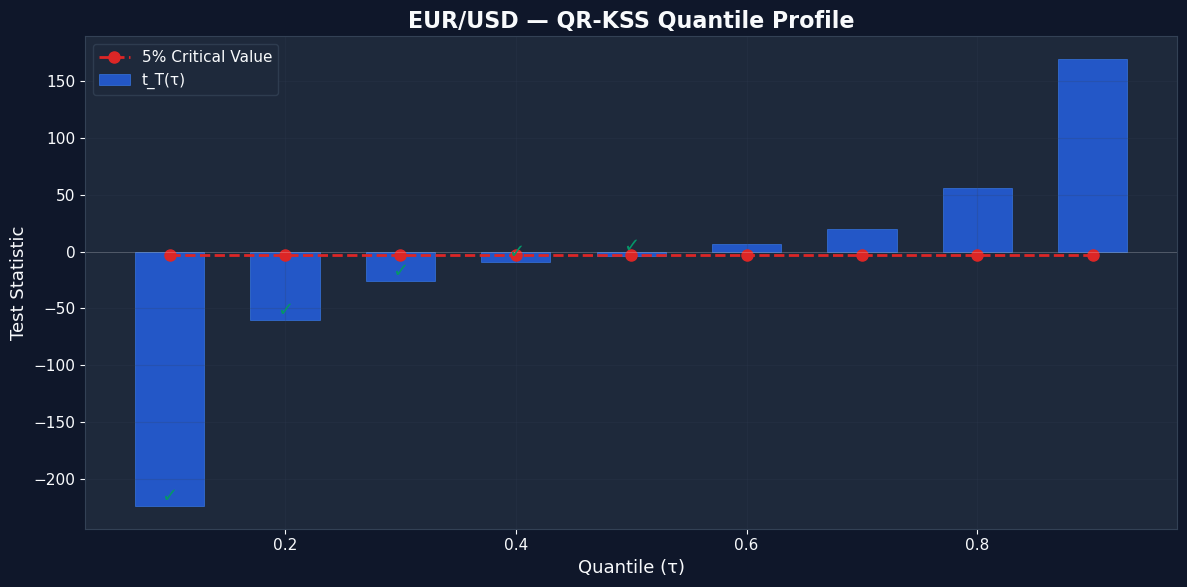

In [14]:
# ── Quantile Profile Visualization ──
setup_style()
fig = hnur.plot_quantile_results(r_qrkss,
    title=f'{series_name} — QR-KSS Quantile Profile')
plt.savefig('fig_qr_kss.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


### 6.2 QR-Fourier-KSS — Bahmani-Oskooee et al. (2020)
One-step quantile regression with Fourier terms **inside the regression**.
Bootstrap critical values under H₀.


In [15]:
# ── 6.2 QR-Fourier-KSS (reduced bootstrap for speed) ──
r_qrfkss = hnur.qr_fourier_kss(y, model=1, pmax=8, k=3, nboot=299)
print(r_qrfkss.summary())



  QR-Fourier-KSS Quantile Unit Root Test
Quantile       t_T(τ)    CV 5%  Reject
----------  ---------  -------  --------
t=0.1       -232.83        nan  No
t=0.2        -66.3398      nan  No
t=0.3        -29.2605      nan  No
t=0.4         -9.1266      nan  No
t=0.5         -3.5748      nan  No
t=0.6          6.3817      nan  No
t=0.7         19.5284      nan  No
t=0.8         64.9528      nan  No
t=0.9        186.927       nan  No

-------------  --------
QKS statistic    232.83
QCM statistic  99145.6
-------------  --------


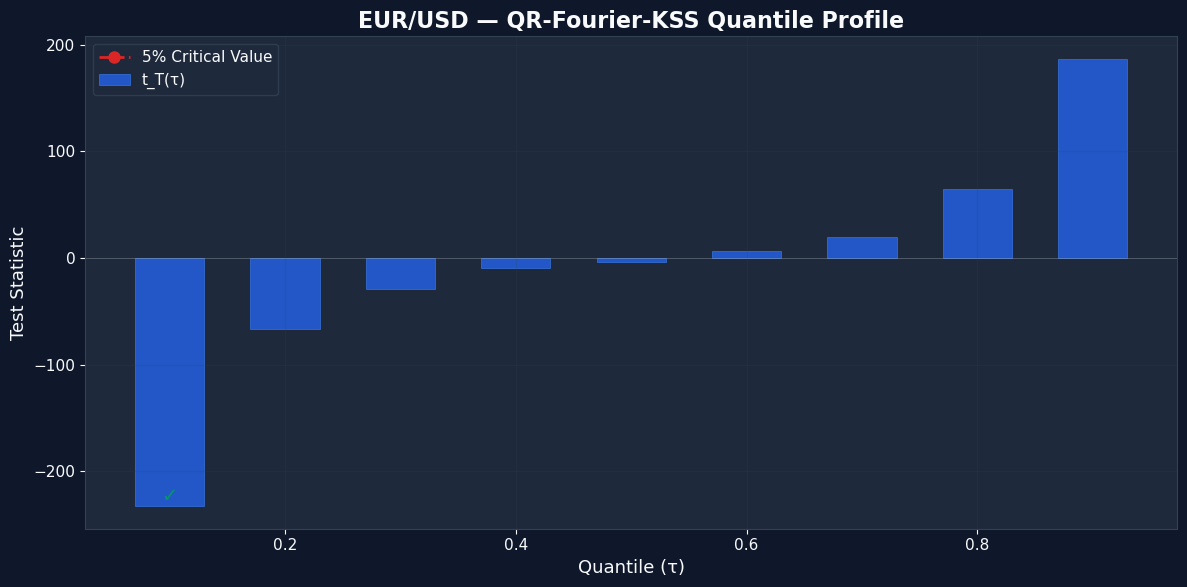

In [16]:
# ── QR-Fourier-KSS Quantile Profile ──
setup_style()
fig = hnur.plot_quantile_results(r_qrfkss,
    title=f'{series_name} — QR-Fourier-KSS Quantile Profile')
plt.savefig('fig_qr_fourier_kss.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


---
## 7. Fractional Fourier & Wavelet Tests

### 7.1 KSS-FF — Omay, Corakci & Hasdemir (2021)
ESTAR test with **fractional Fourier function** that restores Taylor expansion
residuals lost during KSS linearization.


In [17]:
# ── 7.1 KSS-FF ──
r_kssff = hnur.kss_ff(y, model=1, pmax=12)
print(r_kssff.summary())



  KSS-FF Unit Root Test
---------------------  -------------------------------
                 Test  KSS-FF
                Model  Intercept
       Test Statistic  -3.1621
Optimal Frequency (k)  0.9
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -4.1030  |  No
             5% level  -3.5220  |  No
            10% level  -3.2120  |  No

     F-stat (Fourier)  252.5704

            Reference  Omay, Corakci & Hasdemir (2021)
---------------------  -------------------------------


### 7.2 FWKSS — Haar Wavelet + Fourier-KSS
Applies a simple **Haar wavelet** smoothing $(y_t + y_{t+1})/\sqrt{2}$
before running Fourier-KSS on the approximation coefficients.


In [18]:
# ── 7.2 Wavelet-KSS (FWKSS) ──
r_fwkss = hnur.wavelet_kss(y, model=1, pmax=8)
print(r_fwkss.summary())



  FWKSS Unit Root Test
---------------------  -----------------------------------------
                 Test  FWKSS
                Model  Intercept
       Test Statistic  -2.9198
Optimal Frequency (k)  1.0
      Optimal Lag (p)  0

                       Critical Value | Reject H0
             1% level  -4.3500  |  No
             5% level  -3.5500  |  No
            10% level  -3.1700  |  No

     F-stat (Fourier)  117.6122

            Reference  Aydin (FWKSS, Haar wavelet + Fourier-KSS)
---------------------  -----------------------------------------


---
## 8. Comprehensive Comparison Dashboard

### 8.1 Summary Table — All 13 Tests on Primary Series


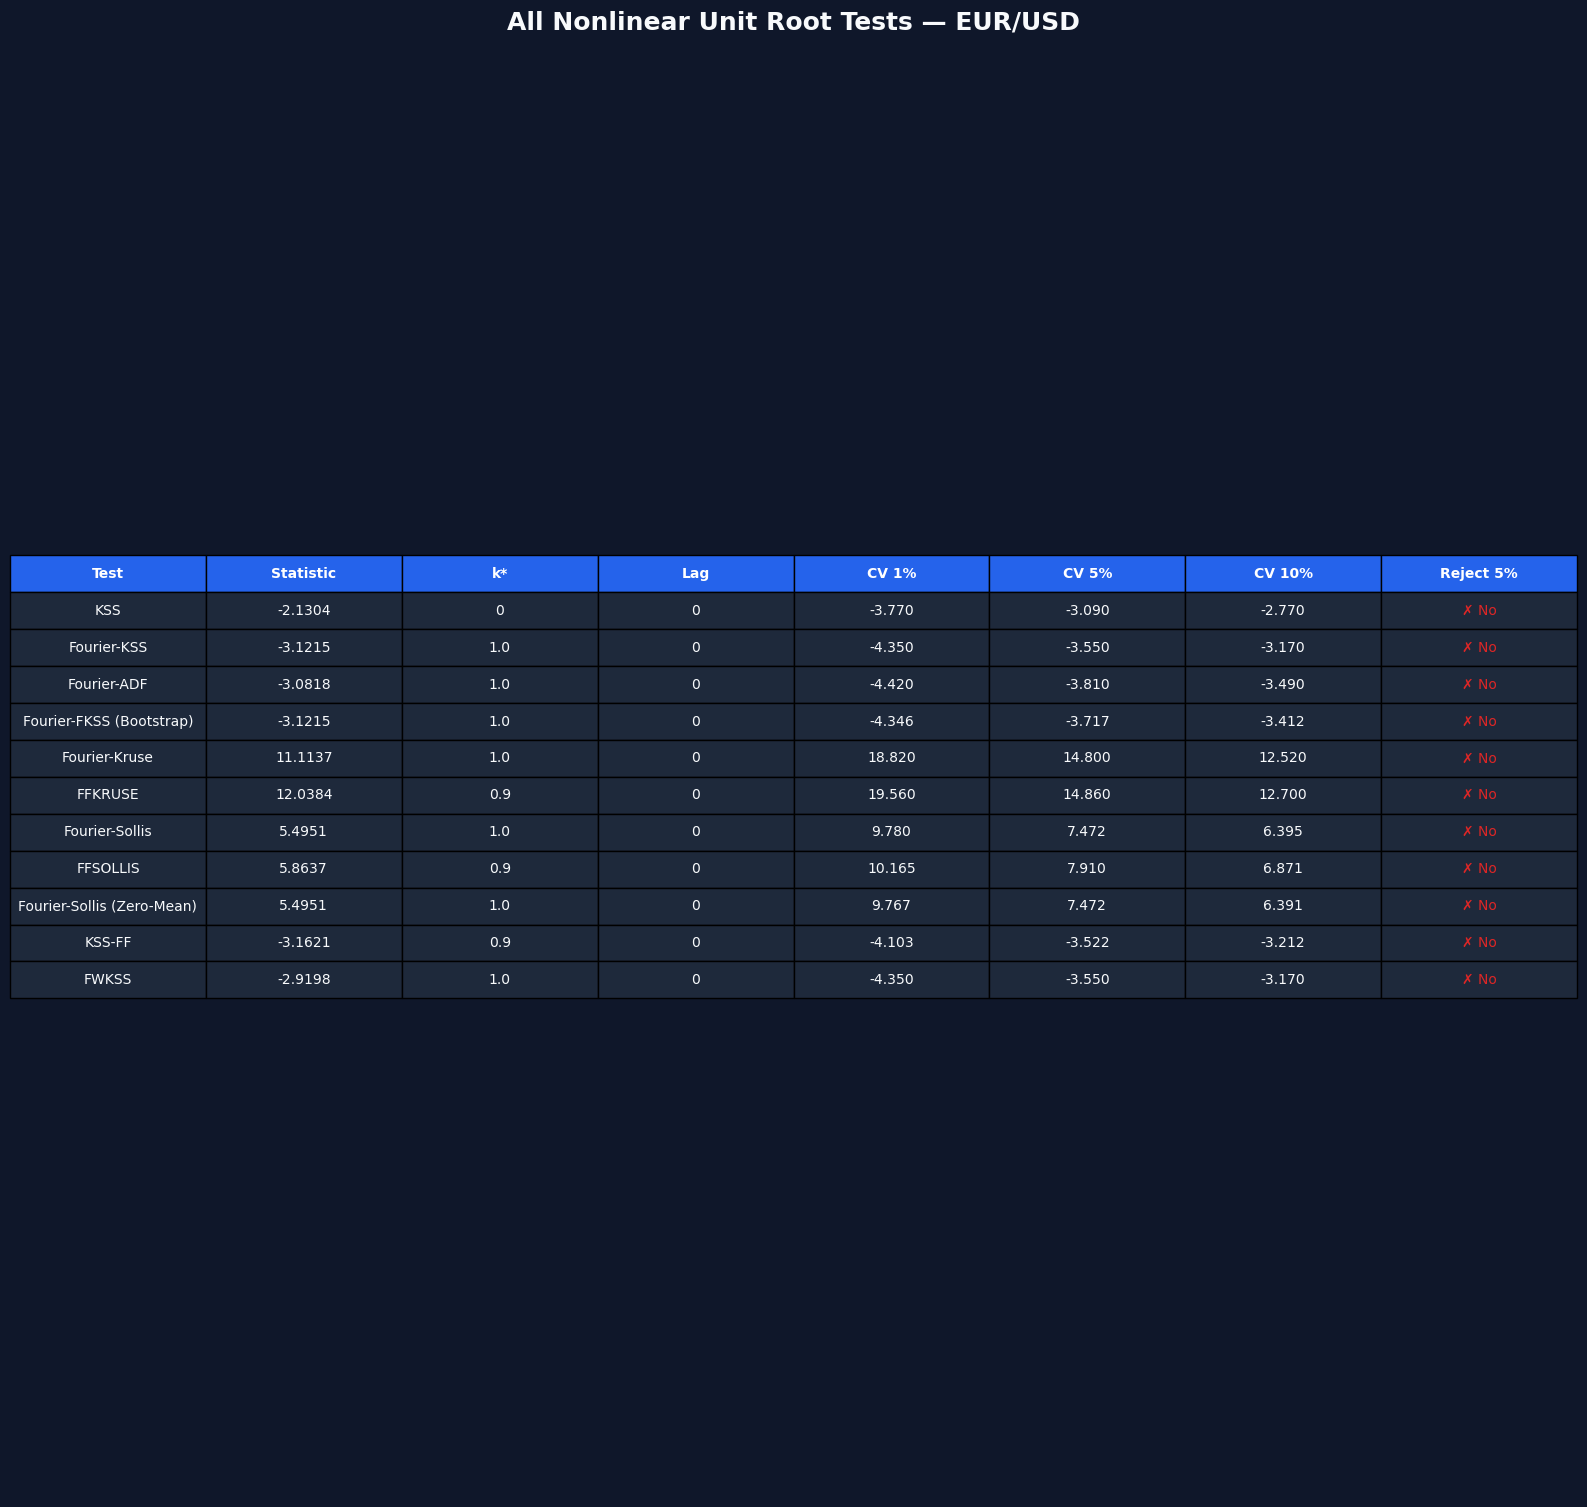

In [19]:
# ── Master comparison table for primary series ──
setup_style()
all_standard = [r_kss, r_fkss, r_fadf, r_boot, r_fkruse, r_ffkruse,
                r_fsollis, r_ffsollis, r_fszm, r_kssff, r_fwkss]
fig = hnur.plot_comparison_table(all_standard,
    title=f'All Nonlinear Unit Root Tests — {series_name}')
plt.savefig('fig_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


In [20]:
# ── Publication-quality HTML table ──
rows = []
for r in all_standard:
    rej = '✓' if r.reject_5 else '✗'
    color = '#10B981' if r.reject_5 else '#EF4444'
    rows.append({
        'Test': r.test_name,
        'Statistic': f'{r.statistic:.4f}',
        'k*': f'{r.optimal_k}',
        'Lag': r.optimal_lag,
        'CV 1%': f'{r.cv_1:.3f}',
        'CV 5%': f'{r.cv_5:.3f}',
        'CV 10%': f'{r.cv_10:.3f}',
        'Reject H₀ (5%)': f'<span style="color:{color};font-weight:bold">{rej}</span>',
    })
df_table = pd.DataFrame(rows)

html = '<h3 style="font-family:sans-serif">Table 1: Unit Root Test Results</h3>'
html += df_table.to_html(escape=False, index=False,
    classes='table', border=0)
html += '<p style="font-size:11px;color:#94A3B8">'
html += 'Note: ✓ = reject H₀ (unit root) at 5%. '
html += 'KSS/Fourier-KSS/ADF use left-tail t-test; '
html += 'Kruse/Sollis use right-tail F/τ-test.</p>'
display(HTML(html))


Test,Statistic,k*,Lag,CV 1%,CV 5%,CV 10%,Reject H₀ (5%)
KSS,-2.1304,0,0,-3.770,-3.090,-2.770,✗
Fourier-KSS,-3.1215,1.0,0,-4.350,-3.550,-3.170,✗
Fourier-ADF,-3.0818,1.0,0,-4.420,-3.810,-3.490,✗
Fourier-FKSS (Bootstrap),-3.1215,1.0,0,-4.346,-3.717,-3.412,✗
Fourier-Kruse,11.1137,1.0,0,18.820,14.800,12.520,✗
FFKRUSE,12.0384,0.9,0,19.560,14.860,12.700,✗
Fourier-Sollis,5.4951,1.0,0,9.780,7.472,6.395,✗
FFSOLLIS,5.8637,0.9,0,10.165,7.910,6.871,✗
Fourier-Sollis (Zero-Mean),5.4951,1.0,0,9.767,7.472,6.391,✗
KSS-FF,-3.1621,0.9,0,-4.103,-3.522,-3.212,✗


### 8.2 Visual: Test Statistics vs Critical Values


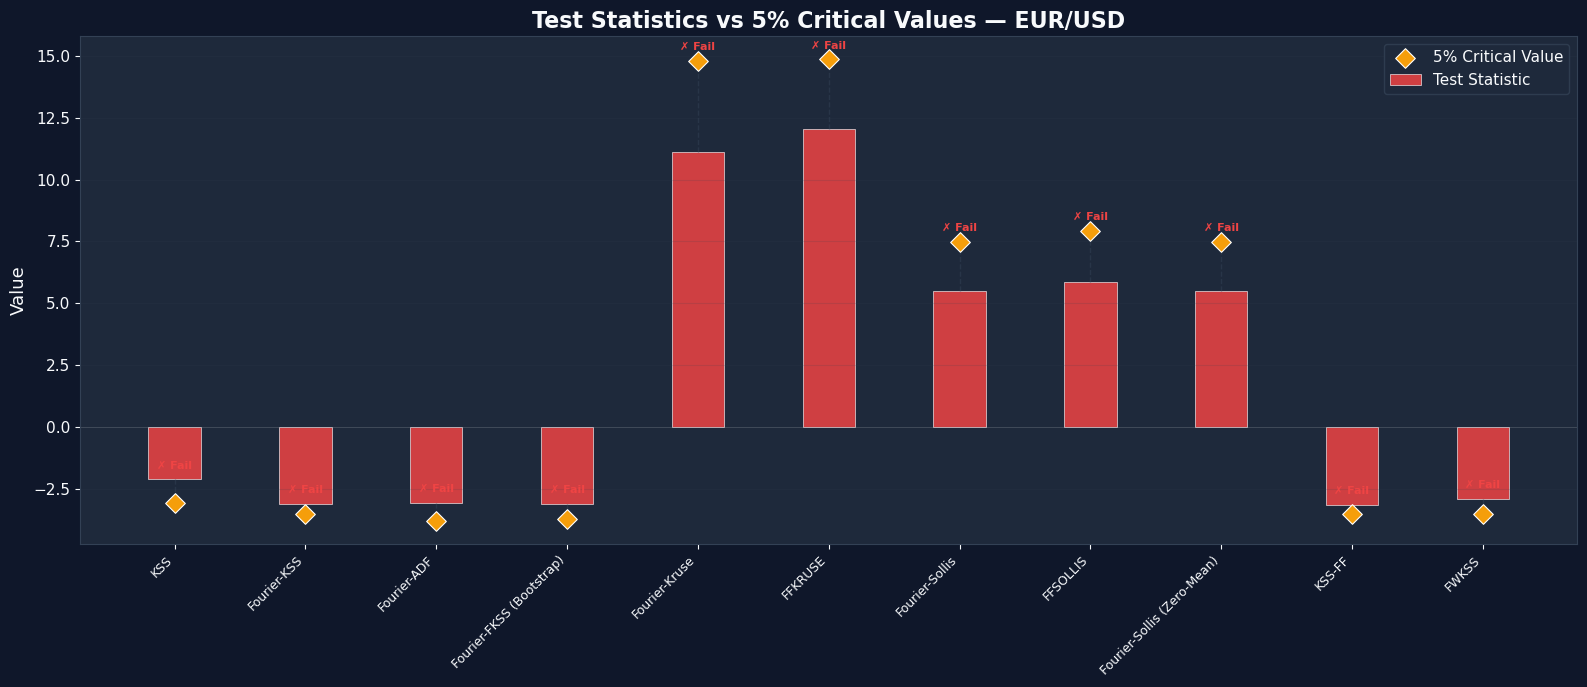

In [21]:
# ── Bar chart: statistics vs 5% CVs ──
setup_style()
fig, ax = plt.subplots(figsize=(16, 7))

names = [r.test_name for r in all_standard]
stats = [r.statistic for r in all_standard]
cvs = [r.cv_5 for r in all_standard]
rejects = [r.reject_5 for r in all_standard]

x = np.arange(len(names))
bar_colors = [COLORS['green'] if rej else COLORS['red'] for rej in rejects]

bars = ax.bar(x, stats, width=0.4, color=bar_colors, alpha=0.85,
              edgecolor='white', linewidth=0.5, label='Test Statistic')
ax.scatter(x, cvs, color=COLORS['amber'], s=100, zorder=5,
           marker='D', edgecolors='white', linewidths=0.8,
           label='5% Critical Value')

# Connect with lines
for i in range(len(x)):
    ax.plot([x[i], x[i]], [stats[i], cvs[i]], '--',
            color=COLORS['grid'], alpha=0.5, lw=1)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Value', fontsize=13)
ax.set_title(f'Test Statistics vs 5% Critical Values — {series_name}',
             fontsize=16, fontweight='bold')
ax.axhline(0, color=COLORS['text'], alpha=0.2, lw=0.5)
ax.legend(facecolor=COLORS['card'], edgecolor=COLORS['grid'],
          fontsize=11, loc='upper right')
ax.grid(True, alpha=0.15, axis='y')

# Annotate rejections
for i, rej in enumerate(rejects):
    label = '✓ Reject' if rej else '✗ Fail'
    color = COLORS['green'] if rej else COLORS['red']
    y_pos = max(stats[i], cvs[i]) + abs(max(stats))*0.03
    ax.text(x[i], y_pos, label, ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('fig_bar_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


---
## 9. Multi-Series Analysis

Apply all 11 standard tests across **all three series** and visualize results as a heatmap.


In [22]:
# ── Run all tests on every series ──
test_fns = [
    ('KSS', lambda y: hnur.kss(y, model=2, pmax=12)),
    ('F-KSS', lambda y: hnur.fourier_kss(y, model=1, pmax=12)),
    ('F-ADF', lambda y: hnur.fourier_adf(y, model=1, pmax=12)),
    ('F-Kruse', lambda y: hnur.fourier_kruse(y, model=1, pmax=12)),
    ('FFKRUSE', lambda y: hnur.ffkruse(y, model=1, pmax=12)),
    ('F-Sollis', lambda y: hnur.fourier_sollis(y, model=1, pmax=12)),
    ('FFSOLLIS', lambda y: hnur.ffsollis(y, model=1, pmax=12)),
    ('F-Sol-ZM', lambda y: hnur.fourier_sollis_zeromean(y, pmax=12)),
    ('KSS-FF', lambda y: hnur.kss_ff(y, model=1, pmax=12)),
    ('FWKSS', lambda y: hnur.wavelet_kss(y, model=1, pmax=8)),
]

multi = {}
for sname, sy in data.items():
    multi[sname] = {}
    for tname, fn in test_fns:
        try:
            r = fn(sy)
            multi[sname][tname] = r
        except Exception as e:
            print(f'  {sname}/{tname}: {e}')
print('Done — all tests computed.')


Done — all tests computed.


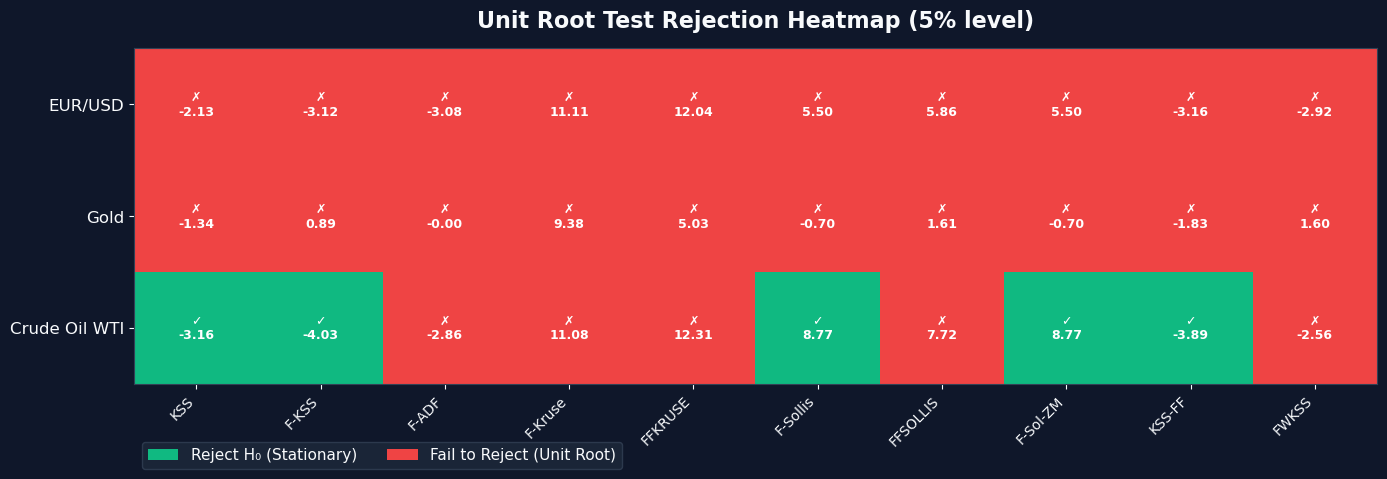

In [23]:
# ── Rejection Heatmap ──
setup_style()
series_names = list(data.keys())
test_names = [t[0] for t in test_fns]

# Build matrix: 1=reject, 0=fail, nan=error
mat = np.full((len(series_names), len(test_names)), np.nan)
stat_mat = np.full((len(series_names), len(test_names)), np.nan)
for i, sn in enumerate(series_names):
    for j, tn in enumerate(test_names):
        r = multi[sn].get(tn)
        if r:
            mat[i, j] = 1.0 if r.reject_5 else 0.0
            stat_mat[i, j] = r.statistic

fig, ax = plt.subplots(figsize=(14, 5))
from matplotlib.colors import ListedColormap
cmap = ListedColormap([COLORS['red'], COLORS['green']])

im = ax.imshow(mat, cmap=cmap, aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(test_names)))
ax.set_xticklabels(test_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(series_names)))
ax.set_yticklabels(series_names, fontsize=12)

# Annotate cells
for i in range(len(series_names)):
    for j in range(len(test_names)):
        if not np.isnan(mat[i, j]):
            txt = '✓' if mat[i, j] == 1 else '✗'
            stat = stat_mat[i, j]
            ax.text(j, i, f'{txt}\n{stat:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')

ax.set_title('Unit Root Test Rejection Heatmap (5% level)',
             fontsize=16, fontweight='bold', pad=15)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=COLORS['green'], label='Reject H₀ (Stationary)'),
              Patch(facecolor=COLORS['red'], label='Fail to Reject (Unit Root)')]
ax.legend(handles=legend_els, loc='upper left',
          bbox_to_anchor=(0, -0.15), ncol=2,
          facecolor=COLORS['card'], edgecolor=COLORS['grid'])

plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()


In [24]:
# ── Full HTML Results Table (all series) ──
rows = []
for sn in series_names:
    for tn in test_names:
        r = multi[sn].get(tn)
        if r:
            rej = '✓' if r.reject_5 else '✗'
            color = '#10B981' if r.reject_5 else '#EF4444'
            rows.append({
                'Series': sn, 'Test': tn,
                'Stat': f'{r.statistic:.4f}',
                'k*': f'{r.optimal_k}', 'Lag': r.optimal_lag,
                'CV 5%': f'{r.cv_5:.3f}',
                'Result': f'<span style="color:{color};font-weight:bold">{rej}</span>',
            })
df_all = pd.DataFrame(rows)
html = '<h3>Table 2: Multi-Series Results</h3>'
html += df_all.to_html(escape=False, index=False, border=0)
display(HTML(html))


Series,Test,Stat,k*,Lag,CV 5%,Result
EUR/USD,KSS,-2.1304,0,0,-3.090,✗
EUR/USD,F-KSS,-3.1215,1.0,0,-3.550,✗
EUR/USD,F-ADF,-3.0818,1.0,0,-3.810,✗
EUR/USD,F-Kruse,11.1137,1.0,0,14.800,✗
EUR/USD,FFKRUSE,12.0384,0.9,0,14.860,✗
EUR/USD,F-Sollis,5.4951,1.0,0,7.472,✗
EUR/USD,FFSOLLIS,5.8637,0.9,0,7.910,✗
EUR/USD,F-Sol-ZM,5.4951,1.0,0,7.472,✗
EUR/USD,KSS-FF,-3.1621,0.9,0,-3.522,✗
EUR/USD,FWKSS,-2.9198,1.0,0,-3.550,✗


---
## 10. Conclusion

This notebook demonstrated all **13 nonlinear unit root tests** in the `hybridnonlinur` library:

- **KSS family** (4 tests): Standard ESTAR, Fourier-enhanced, and bootstrap variants
- **Kruse family** (2 tests): ESTAR with non-zero threshold, integer & fractional Fourier
- **Sollis/AESTAR family** (3 tests): Asymmetric ESTAR with Fourier breaks
- **Quantile family** (2 tests): Distribution-wide unit root testing
- **Advanced** (2 tests): Fractional Fourier KSS and Haar wavelet preprocessing

### Installation
```bash
pip install hybridnonlinur
```

### Citation
```
Roudane, M. (2025). hybridnonlinur: Nonlinear Hybrid Unit Root Tests.
Python package. https://github.com/merwanroudane/hybridnonlinur
```
